# 240907 Revision 8 soil experiment, before rewetting (Griess assay)
- Analysis: Kiseok Lee
- Date: 9/11/24, experiment and measurement of 240901 - 240905 (5 days each)
- Testing Question: N dynamics before rewetting

In [83]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/ik/Pycharm/cascade')
import os
import pandas as pd
import numpy as np
import glob
import pickle
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from datetime import datetime
import importlib

import griess as gr
print(gr.__file__)
import bmgdata as bd
import denitfit as dn

# figure size and font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/ik/Pycharm/cascade/griess.py


## 1. Standard curves with griess assay

### (1) Using bubble removal using well scan (well quadrant bubble correction)

/Users/ik/Pycharm/cascade/data/standards_metadata.csv
None
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2_standard_540.CSV
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2_standard_900.CSV
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2NO3_standard_540.CSV
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2NO3_standard_900.CSV
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0136           0.0083   -1.6417    0.1085
1        2.2898           0.0310   73.9589    0.0000
2

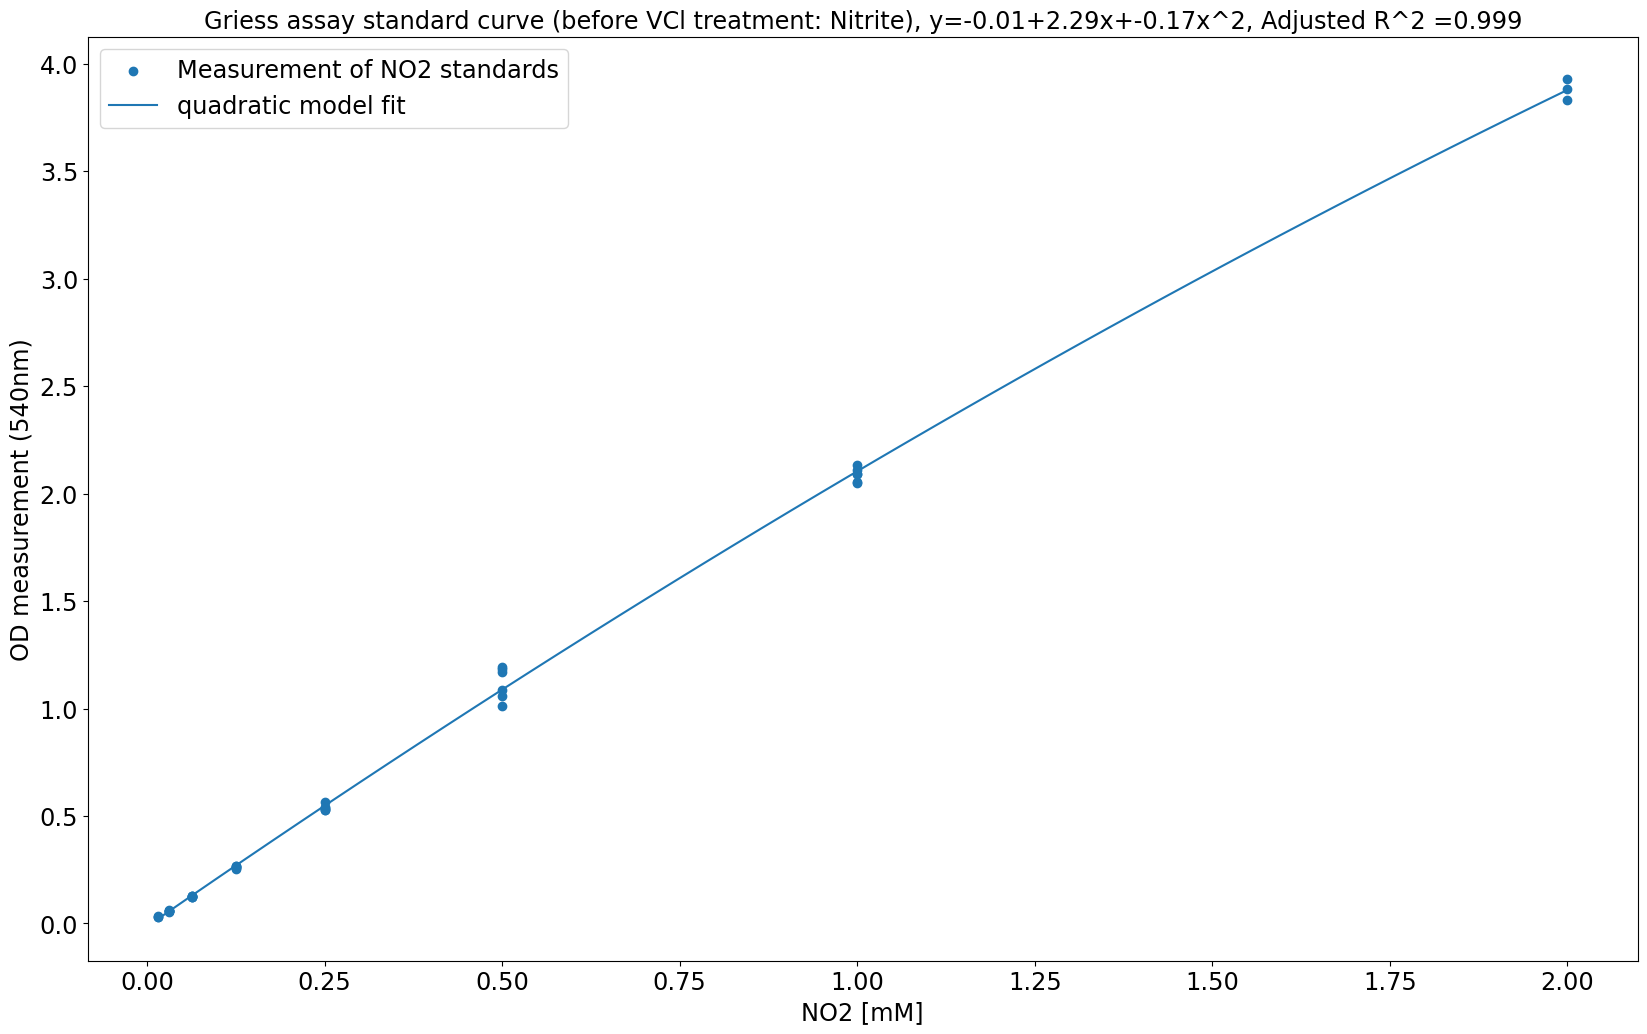

In [77]:
#fit griess assay model using standard curves
std_meta_fn = '/Users/ik/Pycharm/cascade/data_20240914/standard_metadata.csv'
print(std_meta_fn)
std_no2_fn = None
print(std_no2_fn)
std_no2_540_fn = glob.glob("/data_20240914/20240914_Ik_NO2_standard_540.CSV")[0]
print(std_no2_540_fn)
std_no2_900_fn = glob.glob("/data_20240914/20240914_Ik_NO2_standard_900.CSV")[0]
print(std_no2_900_fn)

std_no2no3_fn = None
std_no2no3_540_fn = glob.glob("/data_20240914/20240914_Ik_NO2NO3_standard_540.CSV")[0]
print(std_no2no3_540_fn)
std_no2no3_900_fn = glob.glob("/data_20240914/20240914_Ik_NO2NO3_standard_900.CSV")[0]
print(std_no2no3_900_fn)

# plot standard curve
gr.plot_griess_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
current_date = datetime.now().strftime("%Y%m%d")
plt.savefig(f'/Users/ik/Pycharm/cascade/plots/{current_date}_standard_no2.png')

# fitted parameters
fit_list = gr.fit_griess(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit, no3_fit] = fit_list


Load standard curve

### (2) After VCl treatment (nitrate reduction to nitrite)

[0.009413917098037516, 1.7732277497370563, -0.04141718597291499]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0094           0.0067    1.4109    0.1621
1        1.7732           0.0234   75.8998    0.0000
2       -0.0414           0.0114   -3.6409    0.0005


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          6.938e+04
Date:                Fri, 27 Sep 2024 

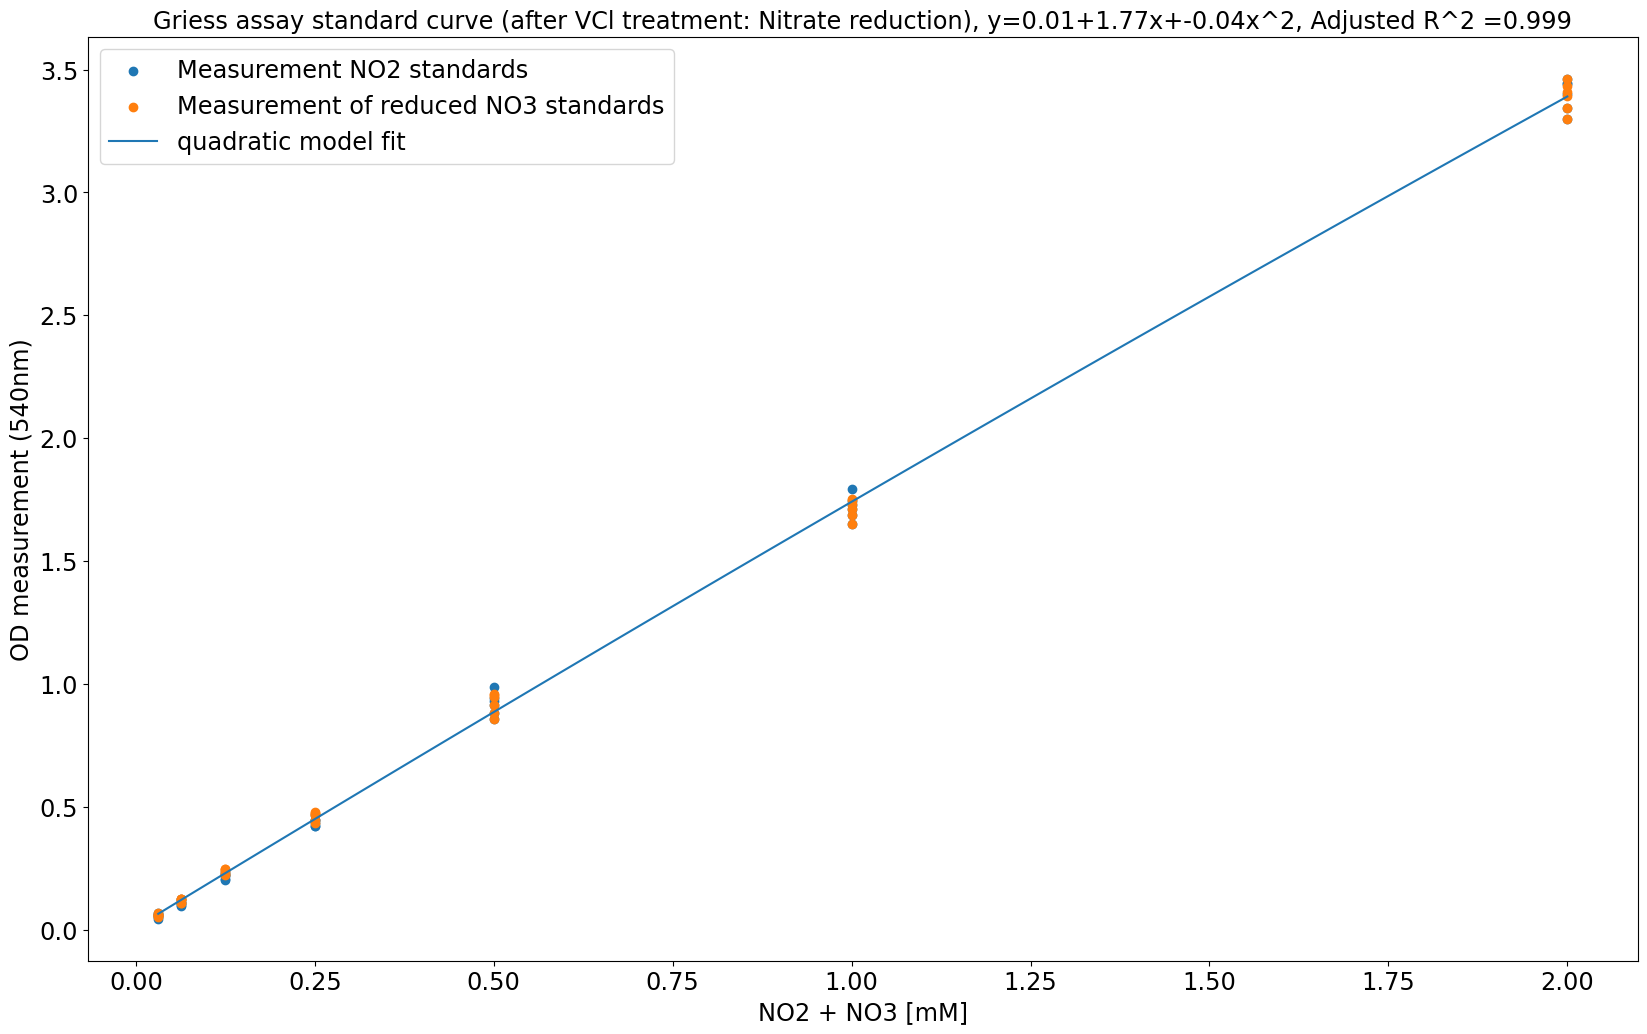

In [78]:
plt.cla()
print(v_fit)

gr.plot_vcl_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'/Users/ik/Pycharm/cascade/plots/{current_date}_standard_no2no3.png')

### (3) Checking the known concentration and the predicted concentration of the NO2-, NO3- mixed standards

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


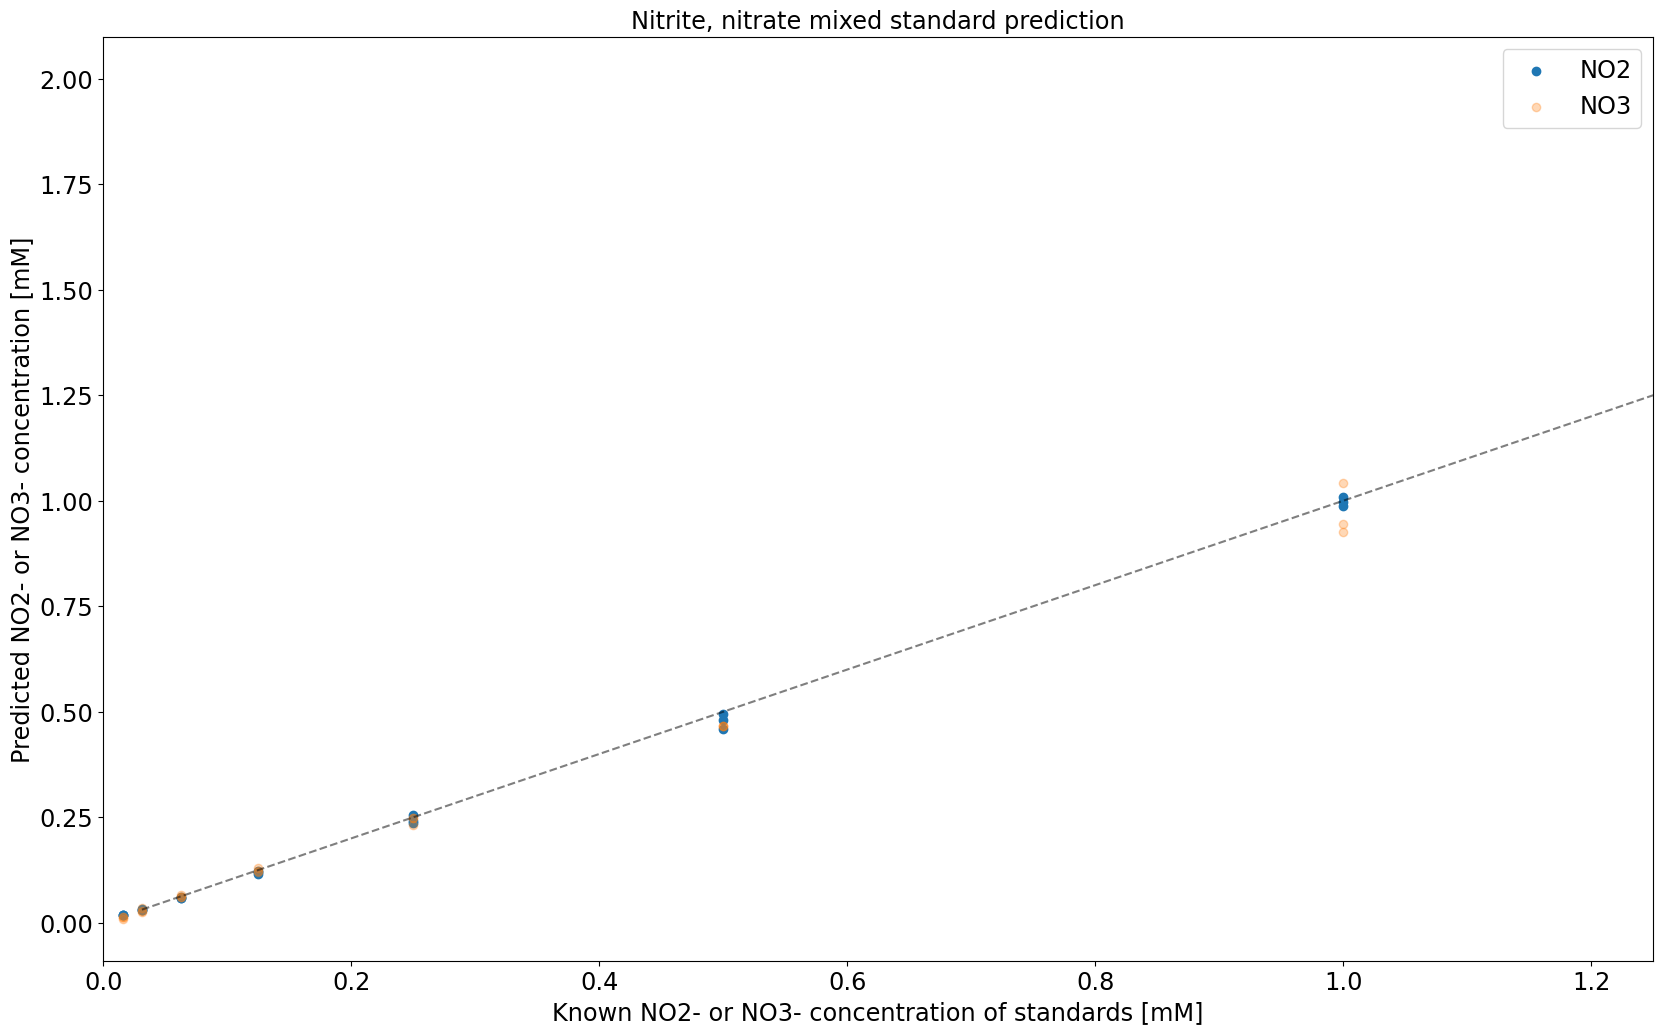

In [79]:
# check mixed conditions prediction
importlib.reload(dn)
gr.plot_mixed_standard_predict(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'/Users/ik/Pycharm/cascade/plots/{current_date}_standard_no2no3_mixed.png')

### (4) Only use nitrate standards for fitting the curve

[0.01646258957747937, 1.8251862809420238, -0.06525398588141237]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0165           0.0089    1.8590    0.0786
1        1.8252           0.0310   58.8652    0.0000
2       -0.0653           0.0151   -4.3223    0.0004


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          3.599e+04
Date:                Fri, 27 Sep 2024  

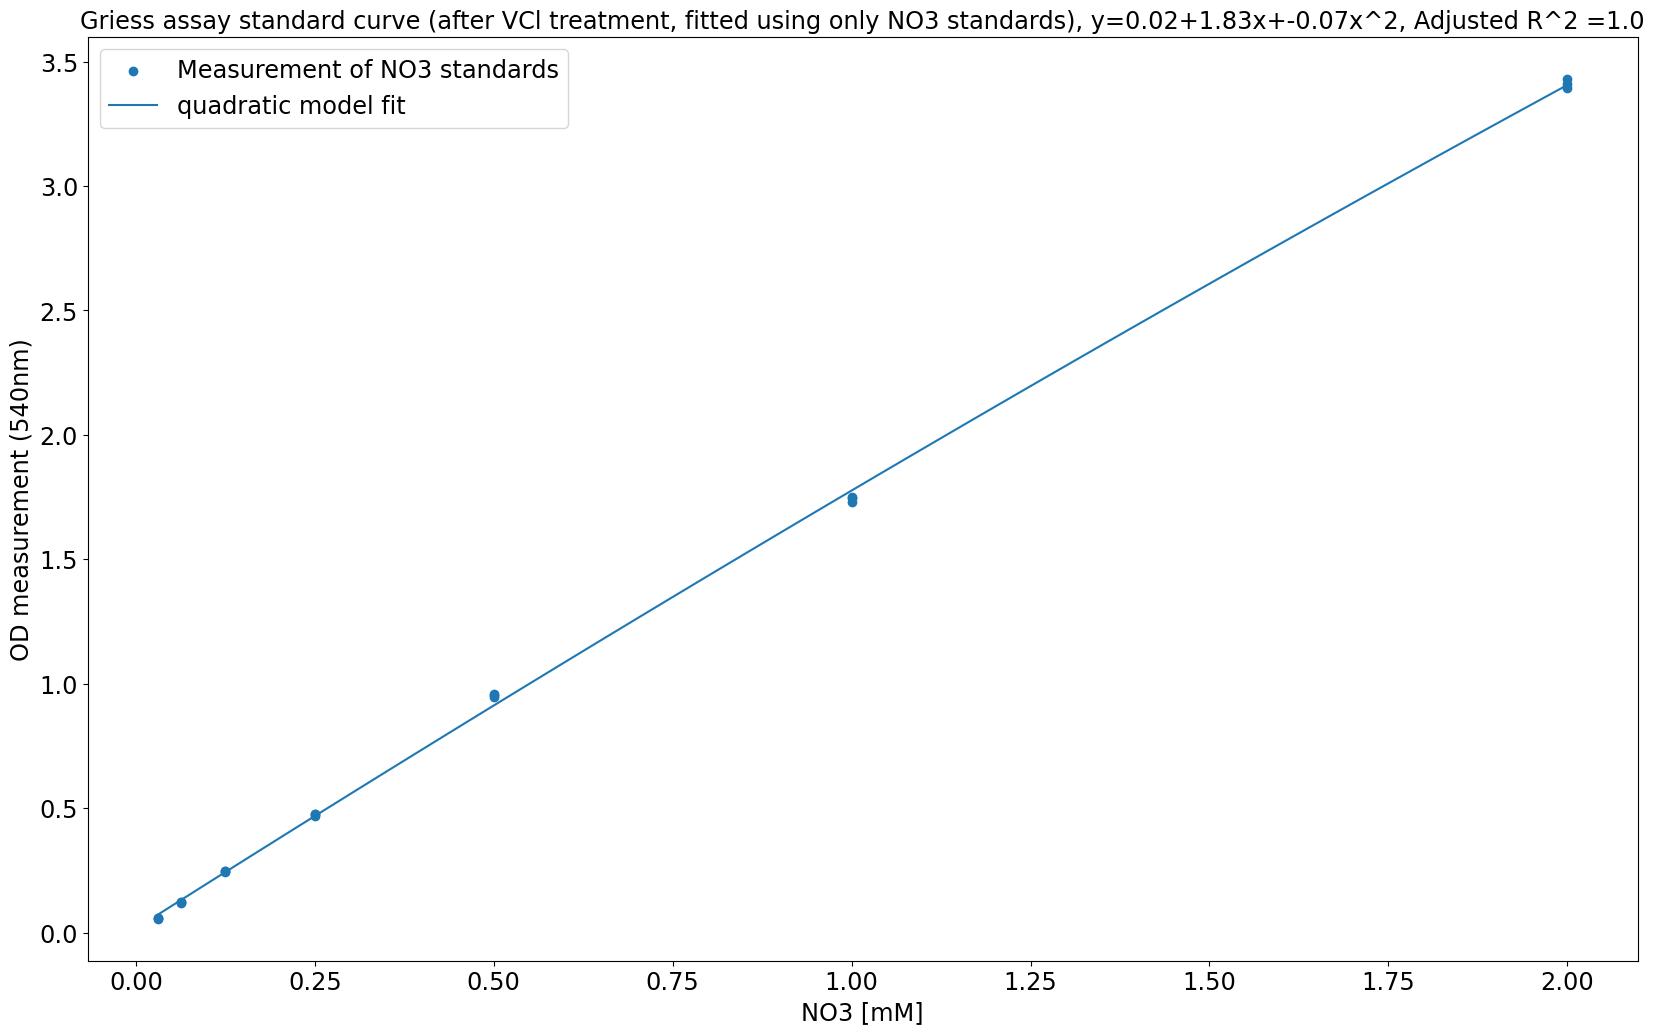

In [80]:
print(no3_fit)

gr.plot_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'/Users/ik/Pycharm/cascade/plots/{current_date}_standard_no3.png')

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


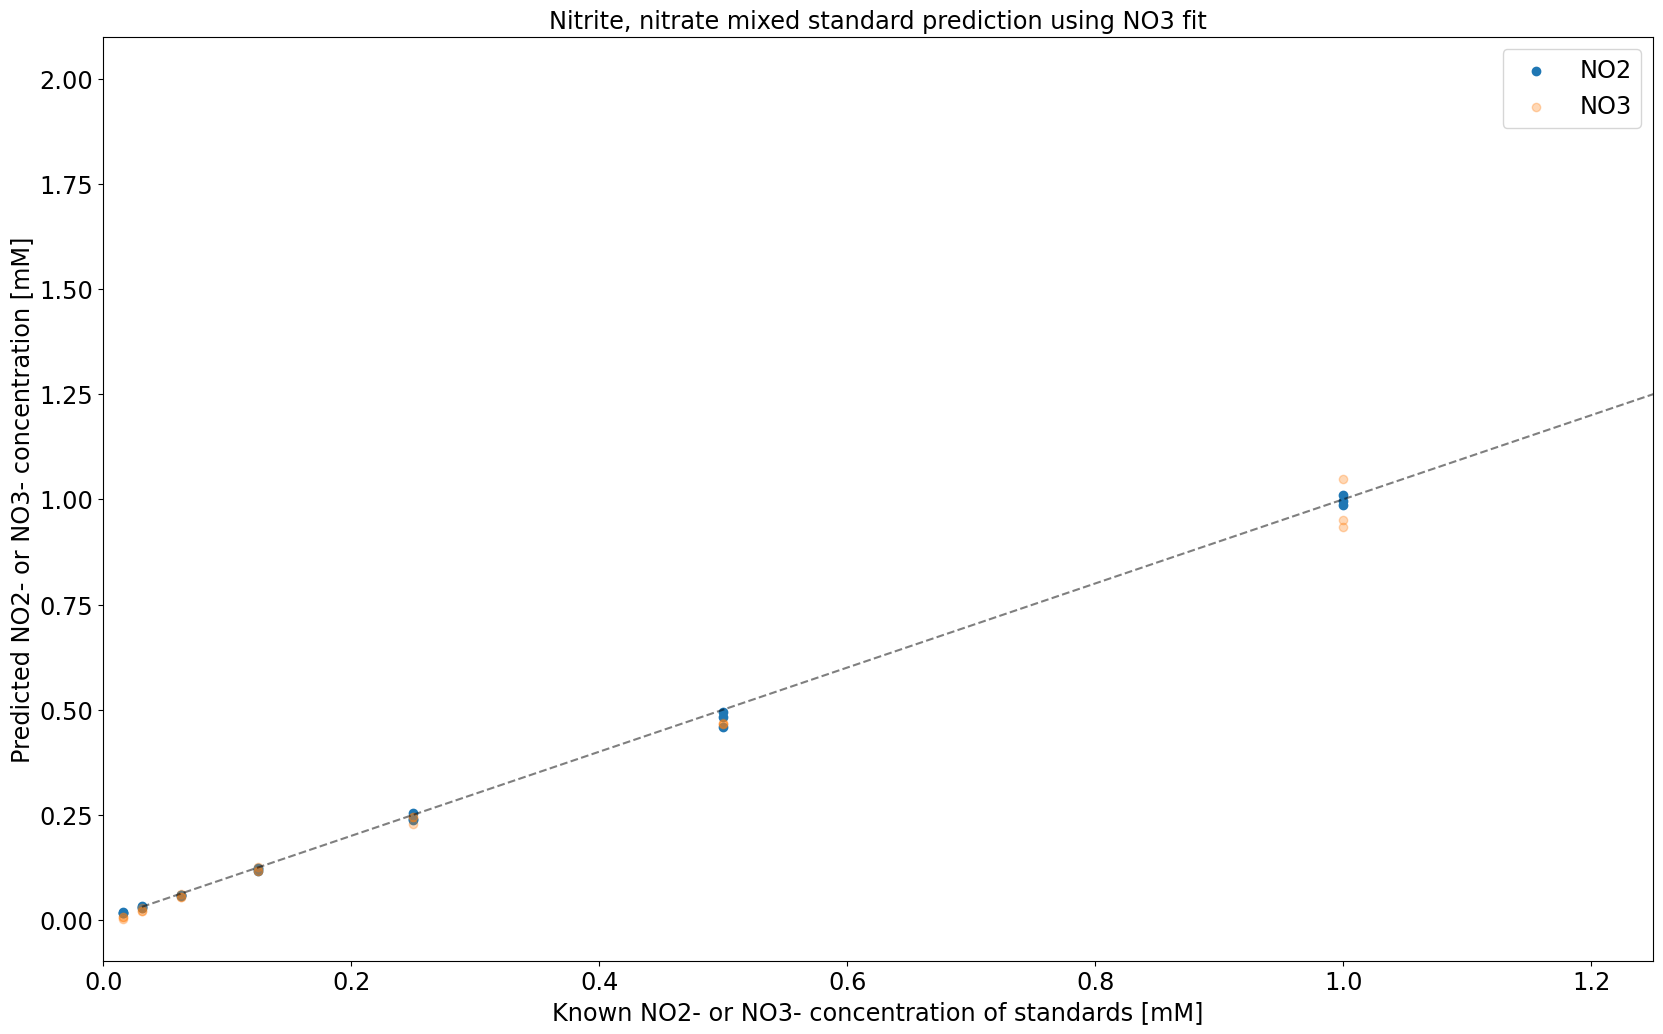

In [81]:
gr.plot_mixed_standard_predict_with_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'/Users/ik/Pycharm/cascade/plots/{current_date}_standard_no3_mixed.png')

## Make sure that the wellscan is removing all outliers from our data.

Check wellscan for outlier removal in NO2


AttributeError: module 'griess' has no attribute 'find_outliers'

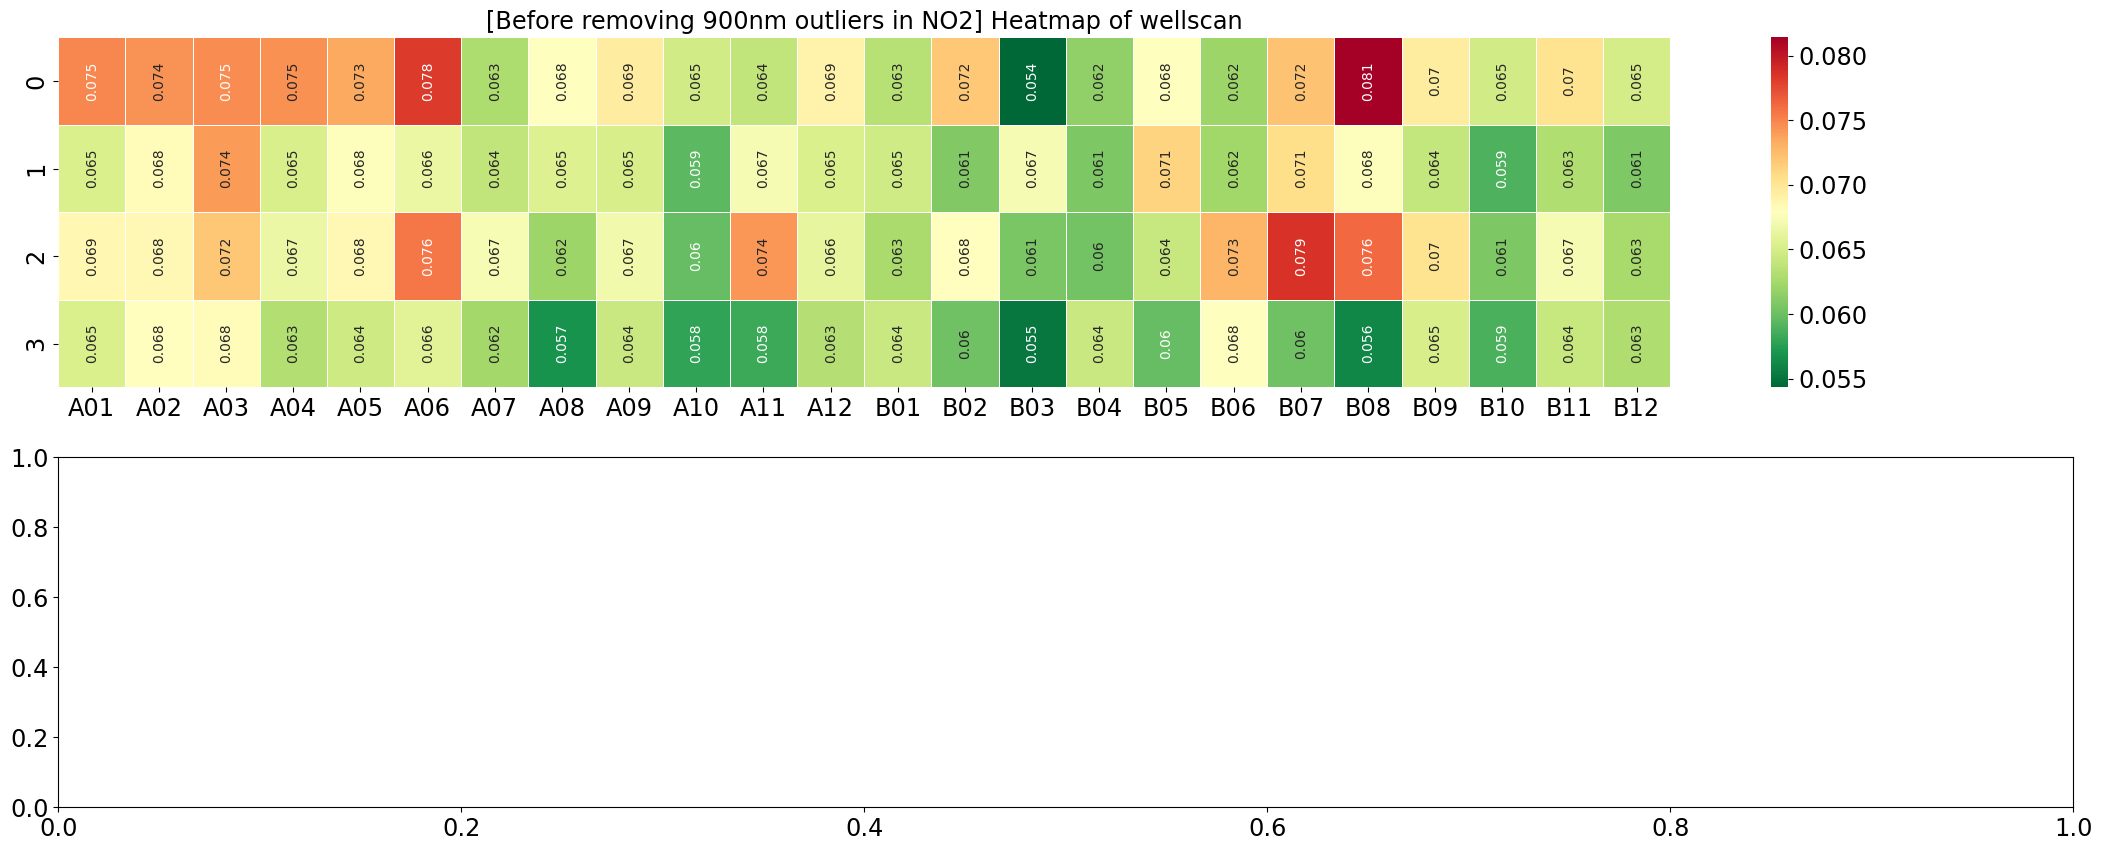

In [82]:
## generate all sample names
#l_soil = ["AW_plate1_2", "Starke3","Oxbow3","Washington2"]
l_soil = ['soil']
l_timepoint = range(8)

gr.get_concentration_xlsx(excel_output = f"/Users/ik/Pycharm/cascade/data_20240914/{current_date}_{sample_name}.xlsx", no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, meta_fn = '/Users/ik/Pycharm/cascade/data_20240914/sample_metadata.csv', no2_fn=None, no2_540_fn = '/Users/ik/Pycharm/cascade/data_20240914/20240914_Ik_NO2_time0_540.CSV', no2_900_fn = '/Users/ik/Pycharm/cascade/data_20240914/20240914_Ik_NO2_time0_900.CSV', no2no3_fn=None, no2no3_540_fn='/Users/ik/Pycharm/cascade/data_20240914/20240915_Ik_NO2NO3_time0_540.CSV', no2no3_900_fn='/Users/ik/Pycharm/cascade/data_20240914/20240915_Ik_NO2NO3_time0_900.CSV')

soil_time0
/Users/ik/Pycharm/cascade/20240907_kiseok/240907_Griess/sample_metadata_RBW12_T0.csv
None
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2_time0_540.CSV
/Users/ik/Pycharm/cascade/data/20240914_Ik_NO2_time0_900.CSV
None
/Users/ik/Pycharm/cascade/data/20240915_Ik_NO2NO3_time0_540_average.csv
/Users/ik/Pycharm/cascade/data/20240915_Ik_NO2NO3_time0_900.CSV
Check wellscan for outlier removal in NO2


AttributeError: module 'griess' has no attribute 'find_outliers'

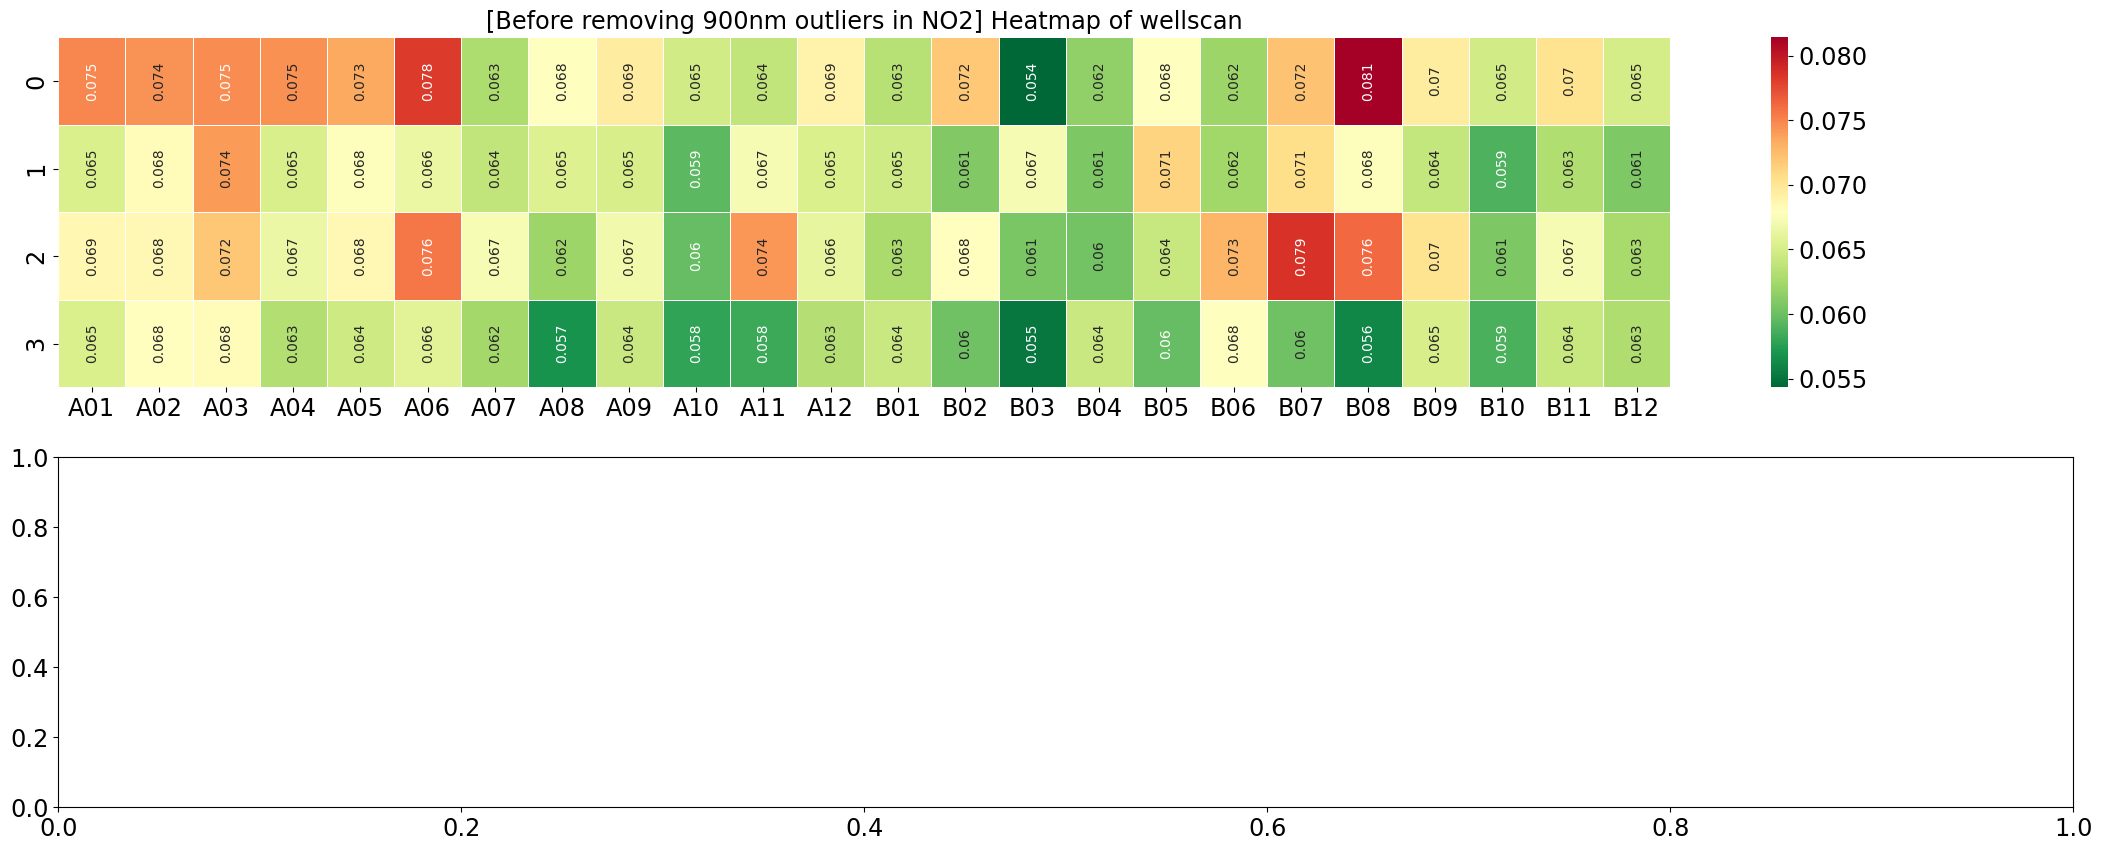

In [26]:
# Loop through sample names
for i in l_soil:
    for j in l_timepoint:
        sample_name = i+f"_time{j}"
        print(sample_name)
        AW_plate1_2_T0_meta_fn = "/Users/ik/Pycharm/cascade/kiseok_20240907/240907_Griess/sample_metadata_RBW12_T0.csv"
        print(AW_plate1_2_T0_meta_fn)
        AW_plate1_2_T0_no2_fn = None
        print(AW_plate1_2_T0_no2_fn)
        AW_plate1_2_T0_no2_540_fn = glob.glob(f"/data_20240914/*_Ik_NO2_time{j}_540*")[0]
        print(AW_plate1_2_T0_no2_540_fn)
        AW_plate1_2_T0_no2_900_fn = glob.glob(f"/data_20240914/*_Ik_NO2_time{j}_900*")[0]
        print(AW_plate1_2_T0_no2_900_fn)
        AW_plate1_2_T0_no2no3_fn = None
        print(AW_plate1_2_T0_no2no3_fn)
        AW_plate1_2_T0_no2no3_540_fn = glob.glob(f"/data_20240914/*_Ik_NO2NO3_time{j}_540*")[0]
        print(AW_plate1_2_T0_no2no3_540_fn)
        AW_plate1_2_T0_no2no3_900_fn = glob.glob(f"/data_20240914/*_Ik_NO2NO3_time{j}_900*")[0]
        print(AW_plate1_2_T0_no2no3_900_fn)

        gr.get_concentration_xlsx(excel_output = f"/Users/ik/Pycharm/cascade/data_20240914/{current_date}_{sample_name}.xlsx", no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, meta_fn = AW_plate1_2_T0_meta_fn, no2_fn=None, no2_540_fn = AW_plate1_2_T0_no2_540_fn, no2_900_fn = AW_plate1_2_T0_no2_900_fn, no2no3_fn=None, no2no3_540_fn=AW_plate1_2_T0_no2no3_540_fn, no2no3_900_fn=AW_plate1_2_T0_no2no3_900_fn)
        
        print("--------------------------------------------------------------------------------------------------------------")

        